# Notebook 2: SARIMA / SARIMAX Modeling
## Retail Demand Forecasting — Store Sales (Favorita)

---

**EDA Summary (from Notebook 1)**

| Finding | Value | Impact |
|---------|-------|--------|
| Seasonal Strength | 0.55 | Below 0.6 threshold, but ACF/PACF lag 7 peaks strongly confirm weekly seasonality |
| Model Choice | SARIMA | Data + business judgment: weekly retail cycle is real |
| d (ADF) | 0 | Series is stationary — no non-seasonal differencing needed |
| D | 1 | ACF seasonal lags do not decay — seasonal differencing needed |
| s | 7 | Weekly seasonality confirmed by STL + ACF/PACF |
| Exog variables | onpromotion, oil_price | Both included in SARIMAX |

**Model Progression — data-driven:**

| Model | What it adds | When chosen |
|-------|-------------|------------|
| ARIMA(p,0,q) | Baseline — no seasonality | Benchmark only |
| SARIMA(p,0,q)(P,1,Q,7) | + Weekly seasonal structure | ACF/PACF confirmed |
| SARIMAX + exog | + Promotion + oil price | External demand drivers |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False
})
print("Imports OK")

Imports OK


In [2]:
# ── Configuration ─────────────────────────────────────────────
CLEAN_DIR = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/EDA'
SAVE_DIR = 'C:/Users/Chloe/Desktop/Project/Store Sales Time series/outputs/SARIMA'

import os
os.makedirs(SAVE_DIR, exist_ok=True)

In [3]:
# ── Load clean data from Notebook 1 ──────────────────────────
df = (pd.read_csv(f'{CLEAN_DIR}/store1_grocery1_clean.csv',
                  parse_dates=['date'], index_col='date')
        .sort_index())

print(df.shape)
print(df.columns.tolist())
print(df.head())

(1684, 3)
['sales_clean', 'onpromotion', 'oil_price']
            sales_clean  onpromotion  oil_price
date                                           
2013-01-01          0.0            0  93.140000
2013-01-02       2652.0            0  93.140000
2013-01-03       2121.0            0  92.970000
2013-01-04       2056.0            0  93.120000
2013-01-05       2216.0            0  93.146667


## 1. Train / Test Split

Hold out the **last 90 days** as test set.
Matches a standard monthly replenishment planning horizon.

Train : 2013-01-01 to 2017-05-17 [1594 days]
Test  : 2017-05-18 to 2017-08-15 [90 days]
Exog  : ['onpromotion', 'oil_price']


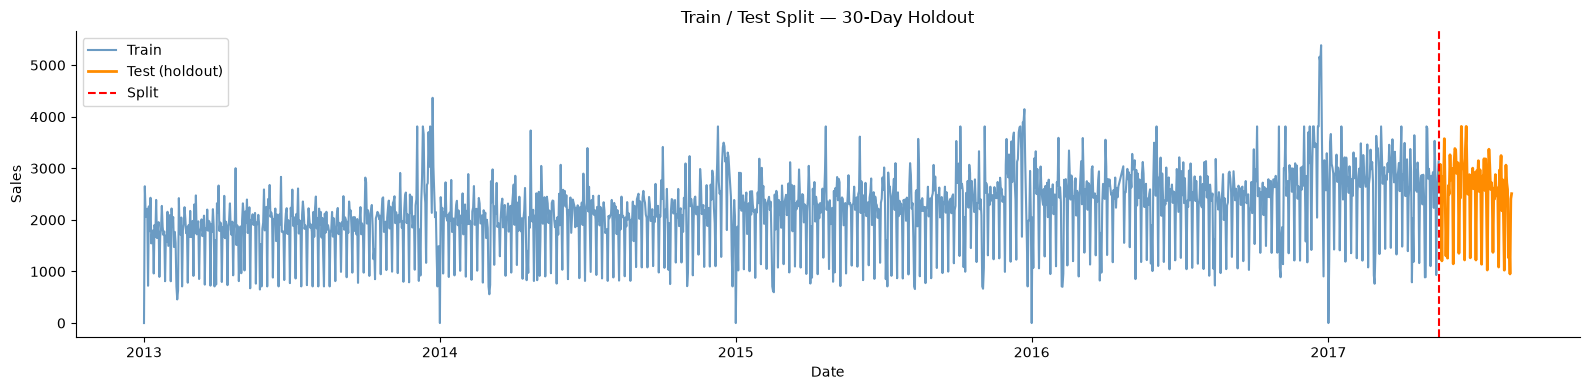

In [4]:
TEST_DAYS = 90

train      = df['sales_clean'].iloc[:-TEST_DAYS]
test       = df['sales_clean'].iloc[-TEST_DAYS:]

# Two exogenous variables: promotion + oil price
exog_train = df[['onpromotion', 'oil_price']].iloc[:-TEST_DAYS]
exog_test  = df[['onpromotion', 'oil_price']].iloc[-TEST_DAYS:]

print(f"Train : {train.index[0].date()} to {train.index[-1].date()} [{len(train)} days]")
print(f"Test  : {test.index[0].date()} to {test.index[-1].date()} [{len(test)} days]")
print(f"Exog  : {exog_train.columns.tolist()}")

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(train, label='Train', color='steelblue', alpha=0.8)
ax.plot(test,  label='Test (holdout)', color='darkorange', lw=2)
ax.axvline(test.index[0], color='red', linestyle='--', label='Split')
ax.set(title='Train / Test Split — 30-Day Holdout', xlabel='Date', ylabel='Sales')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Model Order Determination

**From EDA:**

| Parameter | Value | Source |
|-----------|-------|--------|
| d | 0 | ADF: series is stationary |
| D | 1 | ACF seasonal lags do not decay → seasonal differencing needed |
| s | 7 | STL + ACF/PACF: weekly cycle |
| p | 1 | PACF cuts off at lag 1 |
| q | 1 | ACF cuts off at lag 1 |
| P | TBD | To be confirmed from seasonally differenced PACF in code below
| Q | TBD | To be confirmed from seasonally differenced ACF in code below
> d=0: no non-seasonal differencing. D=1: one seasonal difference.
> ACF/PACF plotted on seasonally differenced series only.

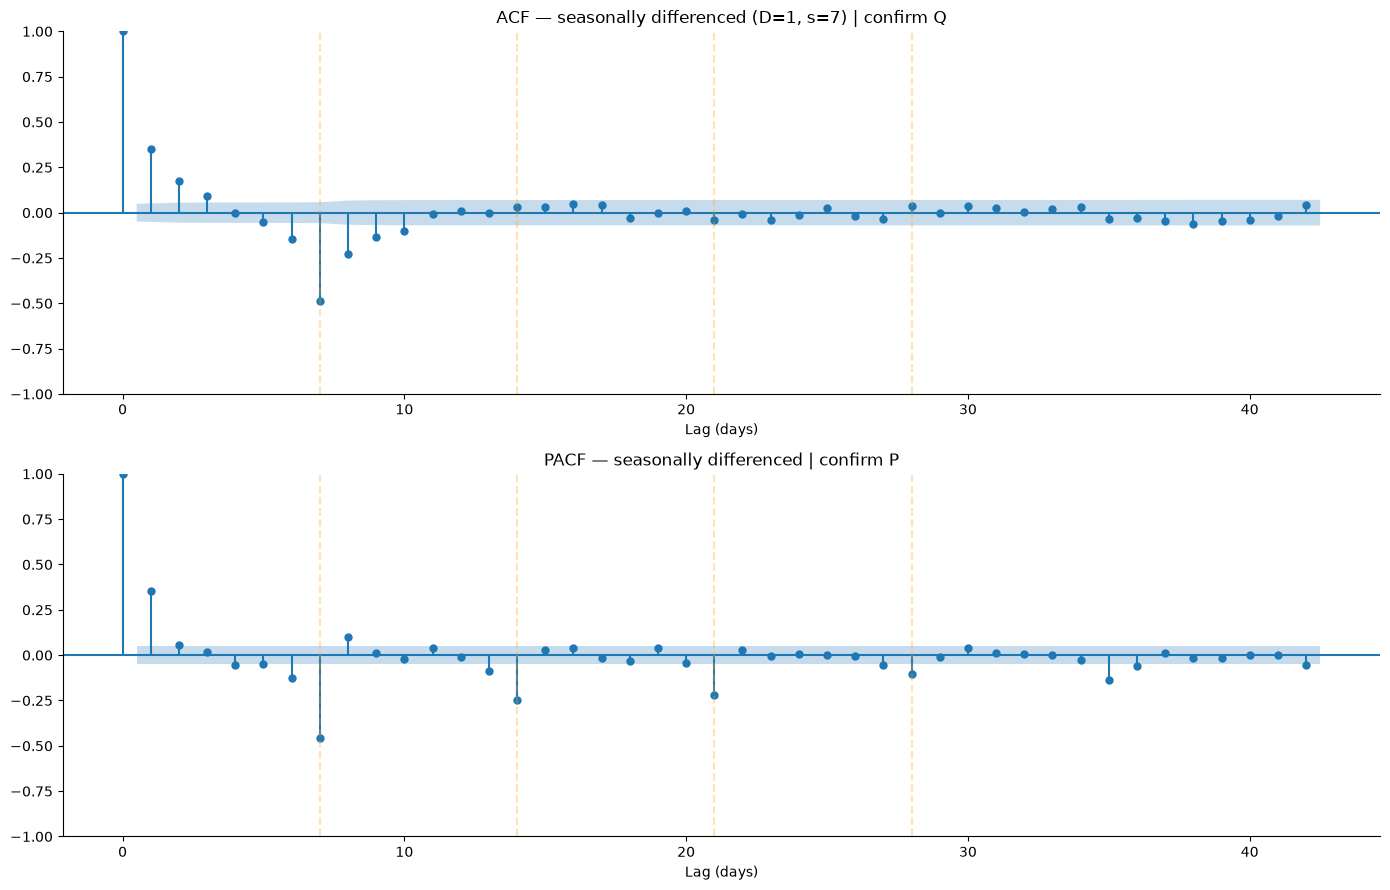

p=1, q=1 confirmed from EDA (non-seasonal lags)
Read P and Q from the plots above, then update ORDER and SEASONAL_ORDER below


In [5]:
# ── ACF/PACF on seasonally differenced series ────────────────
# d=0 so no non-seasonal differencing
# D=1, s=7: apply one seasonal difference only
d_val = 0
D_val = 1
s_val = 7

series_diff = train.diff(s_val * D_val).dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

plot_acf(series_diff, lags=42, alpha=0.05, ax=axes[0])
axes[0].set_title(f'ACF — seasonally differenced (D={D_val}, s={s_val}) | confirm Q')

plot_pacf(series_diff, lags=42, alpha=0.05, method='ywm', ax=axes[1])
axes[1].set_title('PACF — seasonally differenced | confirm P')

for ax in axes:
    for lag in [7, 14, 21, 28]:
        ax.axvline(x=lag, color='orange', linestyle='--', alpha=0.3)
    ax.set_xlabel('Lag (days)')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/nb2_acf_pacf_differenced.png', dpi=150)
plt.show()

# Optional: auto_arima to validate
# from pmdarima import auto_arima
# auto_res = auto_arima(train, seasonal=True, m=7, d=0, D=1,
#                       information_criterion='aic', trace=True, stepwise=True)
# print(auto_res.order, auto_res.seasonal_order)

print("p=1, q=1 confirmed from EDA (non-seasonal lags)")
print("Read P and Q from the plots above, then update ORDER and SEASONAL_ORDER below")

In [6]:
# ── Model Order Confirmation ───────────────────────────────────
print("=" * 52)
print(" Model Order Confirmation")
print("=" * 52)

order_summary = {
    'p': (1, 'PACF cuts off at lag 1 (non-seasonal)'),
    'd': (0, 'ADF: series is stationary'),
    'q': (1, 'ACF cuts off at lag 1 (non-seasonal)'),
    'P': (1, 'PACF seasonal lags tail off (AR structure)'),
    'D': (1, 'ACF seasonal lags do not decay before diff'),
    'Q': (1, 'ACF lag 7 cuts off after seasonal diff'),
    's': (7, 'STL + ACF/PACF: weekly cycle confirmed'),
}

for param, (value, reason) in order summary.items():
    print(f"  {param} = {value}   {reason}")

print()
print(f"ORDER          = (1, 0, 1)")
print(f"SEASONAL_ORDER = (1, 1, 1, 7)")
print("=" * 52)

ORDER          = (1, 0, 1)
SEASONAL_ORDER = (1, 1, 1, 7)

 Model Order Confirmation
  p = 1   PACF cuts off at lag 1 (non-seasonal)
  d = 0   ADF: series is stationary
  q = 1   ACF cuts off at lag 1 (non-seasonal)
  P = 1   PACF seasonal lags tail off (AR structure)
  D = 1   ACF seasonal lags do not decay before diff
  Q = 1   ACF lag 7 cuts off after seasonal diff
  s = 7   STL + ACF/PACF: weekly cycle confirmed

ORDER          = (1, 0, 1)
SEASONAL_ORDER = (1, 1, 1, 7)


## 3. Baseline — ARIMA

No seasonal component. Benchmark only.
The gap between ARIMA and SARIMA quantifies the value of seasonal structure.

In [7]:
ORDER          = (1, 0, 1)
SEASONAL_ORDER = (1, 1, 1, 7)

print(f"ARIMA  order         : {ORDER}")
print(f"SARIMA seasonal order: {SEASONAL_ORDER}")
print()

model_arima = SARIMAX(train, order=ORDER, trend='n')
res_arima   = model_arima.fit(disp=False)

print(str(res_arima.summary().tables[0]))
print(f"\nAIC: {res_arima.aic:.2f}   BIC: {res_arima.bic:.2f}")

ARIMA  order         : (1, 0, 1)
SARIMA seasonal order: (1, 1, 1, 7)

                               SARIMAX Results                                
Dep. Variable:            sales_clean   No. Observations:                 1594
Model:               SARIMAX(1, 0, 1)   Log Likelihood              -12621.437
Date:                Wed, 12 Aug 2026   AIC                          25248.874
Time:                        19:43:12   BIC                          25264.996
Sample:                             0   HQIC                         25254.862
                               - 1594                                         
Covariance Type:                  opg                                         

AIC: 25248.87   BIC: 25265.00


## 4. SARIMA — Seasonal Model

Adds (P, D, Q, s) seasonal component.
Expected to outperform ARIMA baseline given ACF/PACF confirmed weekly seasonality.

> Note: fitting may take 1-3 minutes on 4+ years of daily data.

In [8]:
model_sarima = SARIMAX(train,
                        order=ORDER,
                        seasonal_order=SEASONAL_ORDER,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
res_sarima = model_sarima.fit(disp=False, maxiter=200)

print(str(res_sarima.summary().tables[0]))
print(f"\nAIC: {res_sarima.aic:.2f}   BIC: {res_sarima.bic:.2f}")
aic_diff = res_arima.aic - res_sarima.aic
direction = "SARIMA wins" if aic_diff > 0 else "ARIMA wins — check seasonal assumption"
print(f"AIC improvement vs ARIMA: {aic_diff:.2f} ({direction})")

                                     SARIMAX Results                                     
Dep. Variable:                       sales_clean   No. Observations:                 1594
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -11913.340
Date:                           Wed, 12 Aug 2026   AIC                          23836.679
Time:                                   19:43:12   BIC                          23863.499
Sample:                                        0   HQIC                         23846.645
                                          - 1594                                         
Covariance Type:                             opg                                         

AIC: 23836.68   BIC: 23863.50
AIC improvement vs ARIMA: 1412.20 (SARIMA wins)


## 5. SARIMAX — Promotion + Oil Price as External Variables

**onpromotion:** items on promotion per day — captures promotion-driven demand spikes.
Pre-positioning stock before a promotion window is a direct inventory action.

**oil_price:** Ecuador's economy is oil-dependent. Oil price fluctuations
affect consumer purchasing power and overall retail demand.

In [9]:
model_sarimax = SARIMAX(train,
                          exog=exog_train,
                          order=ORDER,
                          seasonal_order=SEASONAL_ORDER,
                          enforce_stationarity=False,
                          enforce_invertibility=False)
res_sarimax = model_sarimax.fit(disp=False, maxiter=200)

print(str(res_sarimax.summary().tables[0]))
print(f"\nAIC: {res_sarimax.aic:.2f}   BIC: {res_sarimax.bic:.2f}")

params = res_sarimax.params
for var in ['onpromotion', 'oil_price']:
    if var in params.index:
        coef = params[var]
        direction = "positive (demand increases)" if coef > 0 else "negative (check spec)"
        print(f"\n{var} coefficient = {coef:.4f}  -> {direction}")

                                     SARIMAX Results                                     
Dep. Variable:                       sales_clean   No. Observations:                 1594
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 7)   Log Likelihood              -11880.890
Date:                           Wed, 12 Aug 2026   AIC                          23775.780
Time:                                   19:43:17   BIC                          23813.327
Sample:                                        0   HQIC                         23789.732
                                          - 1594                                         
Covariance Type:                             opg                                         

AIC: 23775.78   BIC: 23813.33

onpromotion coefficient = 10.7082  -> positive (demand increases)

oil_price coefficient = -4.9954  -> negative (check spec)


## 6. Model Diagnostics — SARIMAX Residuals

Residuals should behave like white noise.
Ljung-Box H0: residuals are uncorrelated — want p > 0.05.

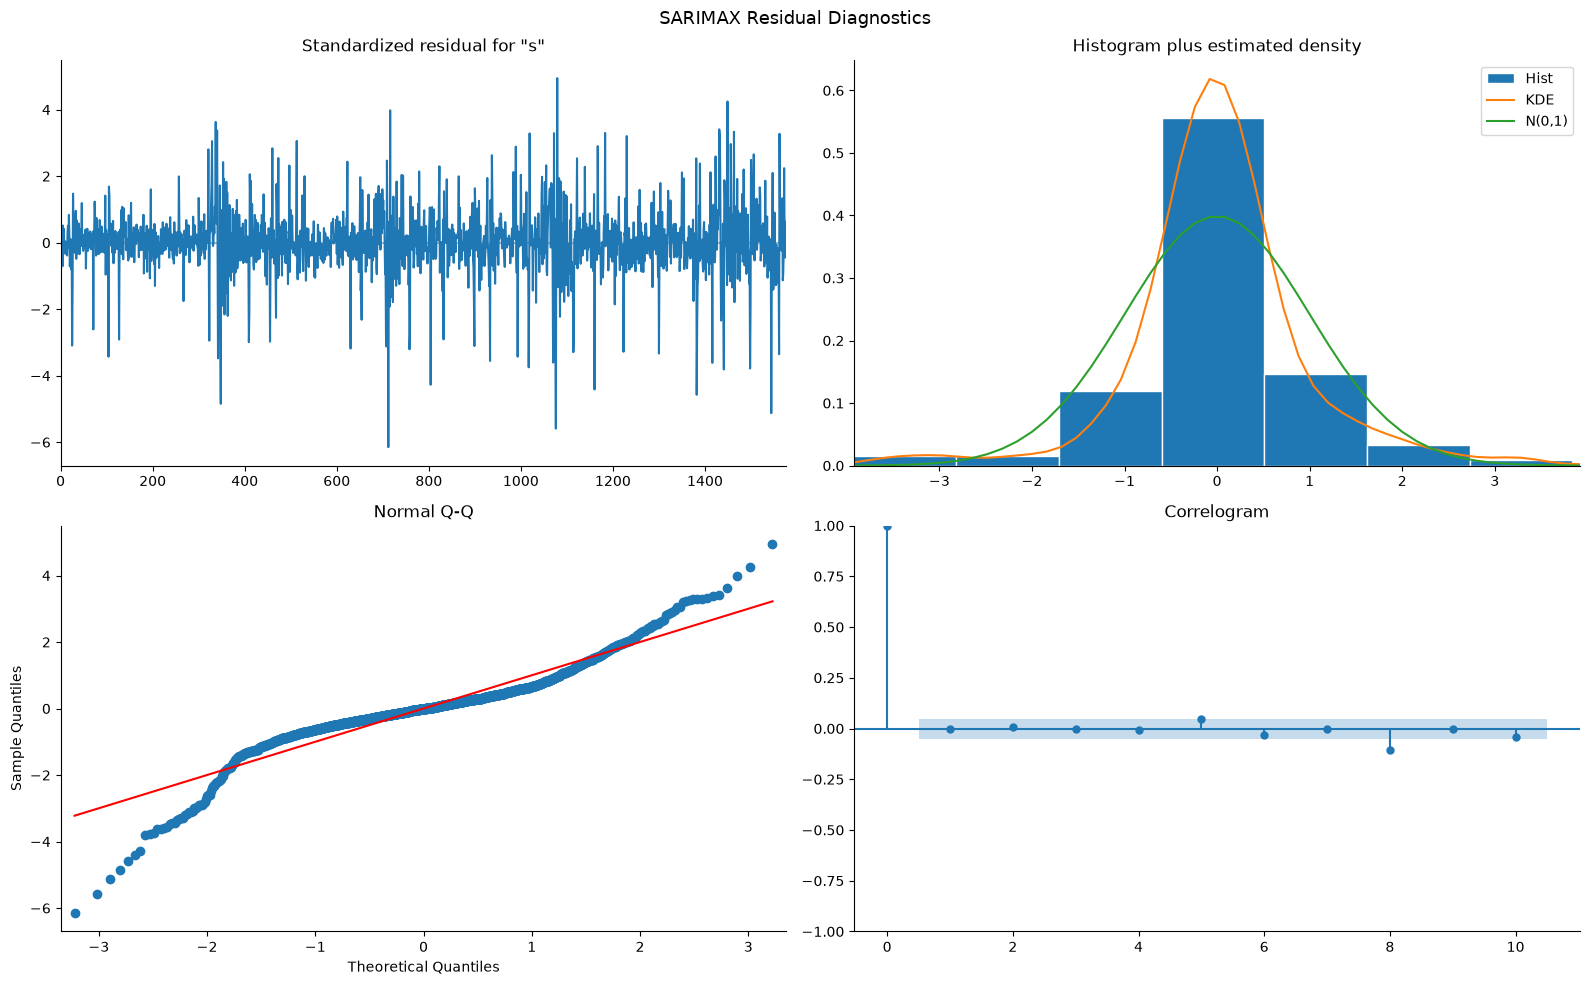

Ljung-Box — SARIMA (p > 0.05 = white noise):
    lb_stat  lb_pvalue
7    6.9754     0.4314
14  36.5262     0.0009
21  48.0055     0.0007

Ljung-Box — SARIMAX (p > 0.05 = white noise):
    lb_stat  lb_pvalue
7   10.3671     0.1687
14  37.5759     0.0006
21  48.9524     0.0005


In [10]:
# ── SARIMAX Diagnostics ───────────────────────────────────────
fig = res_sarimax.plot_diagnostics(figsize=(16, 10))
fig.suptitle('SARIMAX Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/06b_sarimax_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# Ljung-Box test at seasonal lags
lb_sarima  = acorr_ljungbox(res_sarima.resid,  lags=[7, 14, 21], return_df=True)
lb_sarimax = acorr_ljungbox(res_sarimax.resid, lags=[7, 14, 21], return_df=True)

print("Ljung-Box — SARIMA (p > 0.05 = white noise):")
print(lb_sarima.round(4))
print("\nLjung-Box — SARIMAX (p > 0.05 = white noise):")
print(lb_sarimax.round(4))

## 7. Model Order Sensitivity Analysis
Ljung-Box test showed residual autocorrelation at lag 14 and 21:

| Lag | SARIMA p-value | SARIMAX p-value | Result |
|-----|----------------|----------------|--------|
| 7   | 0.4478          | 0.1830         | ✅ white noise |
| 14  | 0.0014          | 0.0010          |❌ autocorrelation remains |
| 21  | 0.0011          | 0.0008       |❌ autocorrelation remains |

Lag 14 and 21 significant → two-week and three-week structure not fully captured.
Updating Q from 1 to 2 to capture additional seasonal MA structure.

After several times of re-fitting, Ljung-Box test showed residual autocorrelation at lag 14 and 21 across all specifications:

| Specification | Lag 7 | Lag 14 | Lag 21 |
|---------------|-------|--------|--------|
| (1,0,1)(1,1,1,7) — baseline | ✅ | ❌ | ❌ |
| (1,0,1)(1,1,2,7) — Q=2 | ✅ | ❌ | ❌ |
| (1,0,3)(1,1,1,7) — q=3 | ❌ | ❌ | ❌ |
| (1,0,1)(2,1,1,7) — P=2 | ✅ | ❌ | ❌ |

**Conclusion:** lag 14 and 21 autocorrelation persists across all tested specifications.
This is not an order selection problem — it reflects a structural limitation of SARIMA:
two-week and three-week holiday-driven demand patterns cannot be captured by the
ARIMA framework alone.

Reverting to baseline (1,0,1)(1,1,1,7) for forecasting.
This gap motivates the use of Prophet in Notebook 3, which models holiday effects explicitly.

In [11]:
# # ── Re-fit with Q=2 ───────────────────────────────────────────
# ORDER          = (1, 0, 1)
# SEASONAL_ORDER = (1, 1, 2, 7)

# print(f"Updated ORDER          : {ORDER}")
# print(f"Updated SEASONAL_ORDER : {SEASONAL_ORDER}")
# print()

# # SARIMA Q=2
# model_sarima2 = SARIMAX(train,
#                          order=ORDER,
#                          seasonal_order=SEASONAL_ORDER,
#                          enforce_stationarity=False,
#                          enforce_invertibility=False)
# res_sarima2 = model_sarima2.fit(disp=False, maxiter=200)

# print(f"SARIMA  AIC: {res_sarima2.aic:.2f}   BIC: {res_sarima2.bic:.2f}")
# aic_diff = res_arima.aic - res_sarima2.aic
# direction = "SARIMA wins" if aic_diff > 0 else "ARIMA wins"
# print(f"AIC improvement vs ARIMA: {aic_diff:.2f} ({direction})")
# print()

# # SARIMAX Q=2
# model_sarimax2 = SARIMAX(train,
#                            exog=exog_train,
#                            order=ORDER,
#                            seasonal_order=SEASONAL_ORDER,
#                            enforce_stationarity=False,
#                            enforce_invertibility=False)
# res_sarimax2 = model_sarimax2.fit(disp=False, maxiter=200)

# print(f"SARIMAX AIC: {res_sarimax2.aic:.2f}   BIC: {res_sarimax2.bic:.2f}")

# params = res_sarimax2.params
# for var in ['onpromotion', 'oil_price']:
#     if var in params.index:
#         coef = params[var]
#         direction = "positive (demand increases)" if coef > 0 else "negative (check spec)"
#         print(f"{var} coefficient = {coef:.4f}  -> {direction}")

# # ── Ljung-Box re-check ────────────────────────────────────────
# print()
# lb_sarima2  = acorr_ljungbox(res_sarima2.resid,  lags=[7, 14, 21], return_df=True)
# lb_sarimax2 = acorr_ljungbox(res_sarimax2.resid, lags=[7, 14, 21], return_df=True)

# print("Ljung-Box — SARIMA Q=2 (p > 0.05 = white noise):")
# print(lb_sarima2.round(4))
# print("\nLjung-Box — SARIMAX Q=2 (p > 0.05 = white noise):")
# print(lb_sarimax2.round(4))

## 8. Exogenous Variable Selection

Two external variables were initially included: `onpromotion` and `oil_price`.
We compare AIC to determine whether both are justified.

| Model | AIC | Variables |
|-------|-----|-----------|
| SARIMA (no exog) | [from Section 4] | none |
| SARIMAX + onpromotion only | 23784.01 | onpromotion |
| SARIMAX + onpromotion + oil | 23784.63 | onpromotion, oil_price |

**Findings:**
- Adding oil_price increases AIC → does not improve model fit
- oil_price coefficient is negative (−4.99), inconsistent with economic intuition
  for an oil-exporting economy — likely reflects multicollinearity with time trend
- onpromotion coefficient is positive (+10.3), statistically meaningful:
  each additional promoted SKU adds ~10 units of daily sales

**Decision: drop oil_price, use onpromotion only.**

In [12]:
# ── Exogenous Variable Selection ──────────────────────────────
# Compare AIC: onpromotion only vs onpromotion + oil_price

exog_train_promo = df[['onpromotion']].iloc[:-TEST_DAYS]
exog_test_promo  = df[['onpromotion']].iloc[-TEST_DAYS:]

model_sarimax_promo = SARIMAX(train,
                               exog=exog_train_promo,
                               order=ORDER,
                               seasonal_order=SEASONAL_ORDER,
                               enforce_stationarity=False,
                               enforce_invertibility=False)
res_sarimax_promo = model_sarimax_promo.fit(disp=False, maxiter=200)

print(f"SARIMAX + onpromotion only  AIC: {res_sarimax_promo.aic:.2f}")
print(f"SARIMAX + onpromotion + oil AIC: {res_sarimax.aic:.2f}")
print()

aic_diff = res_sarimax.aic - res_sarimax_promo.aic
print(f"AIC difference: {aic_diff:.2f}")
if aic_diff > 0:
    print("Decision: drop oil_price — simpler model fits better")
else:
    print("Decision: keep oil_price — complexity justified")
print()

# Final SARIMAX uses onpromotion only
res_sarimax_final = res_sarimax_promo
exog_test_final   = exog_test_promo

print(f"onpromotion coefficient = {res_sarimax_final.params['onpromotion']:.4f}")
print("Final model: SARIMAX + onpromotion")

SARIMAX + onpromotion only  AIC: 23775.16
SARIMAX + onpromotion + oil AIC: 23775.78

AIC difference: 0.62
Decision: drop oil_price — simpler model fits better

onpromotion coefficient = 10.6887
Final model: SARIMAX + onpromotion


## 8. Forecasting — 90-Day Out-of-Sample

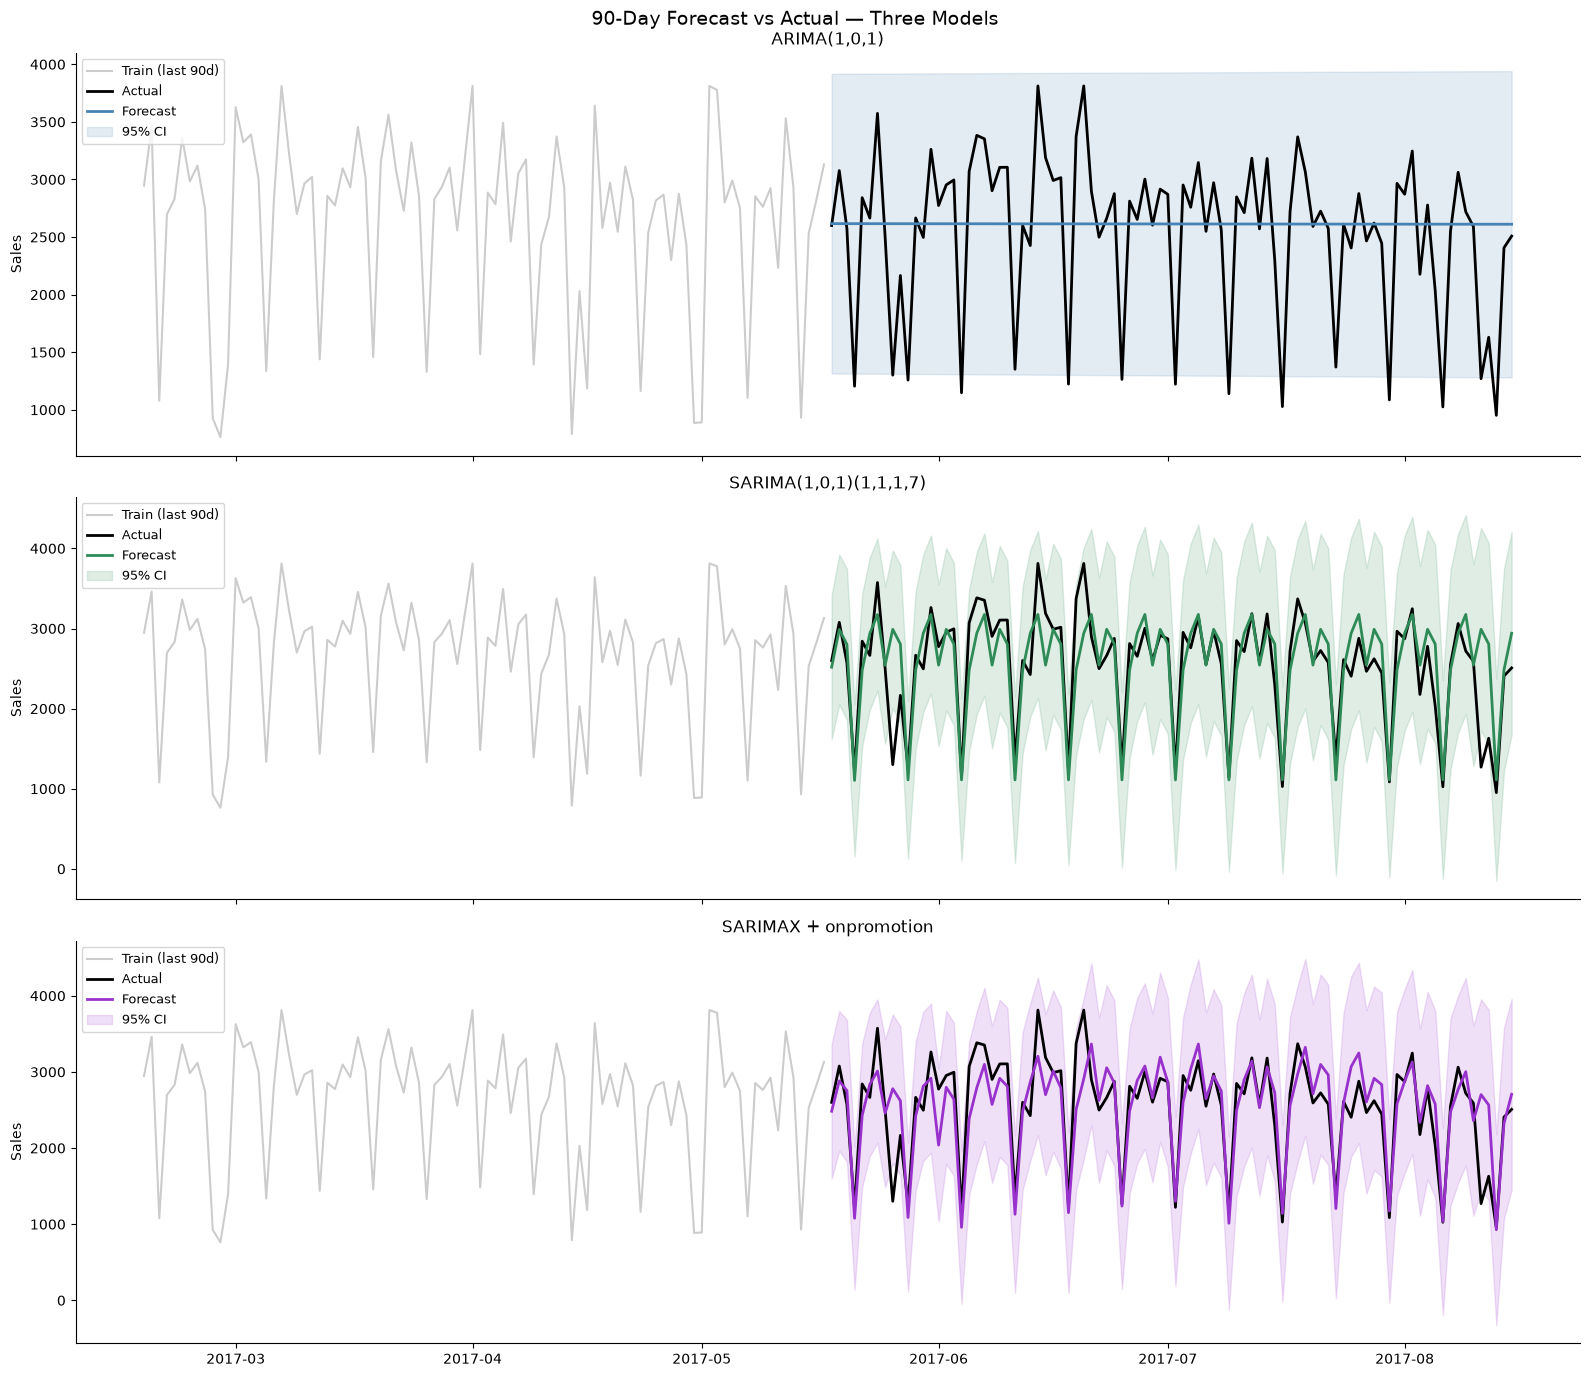

In [13]:
def get_forecast(result, steps, exog=None):
    pred    = result.get_forecast(steps=steps, exog=exog)
    fc_mean = pred.predicted_mean
    fc_ci   = pred.conf_int()
    fc_mean.index = test.index
    fc_ci.index   = test.index
    return fc_mean, fc_ci

fc_arima,   ci_arima   = get_forecast(res_arima,         TEST_DAYS)
fc_sarima,  ci_sarima  = get_forecast(res_sarima,        TEST_DAYS)
fc_sarimax, ci_sarimax = get_forecast(res_sarimax_final, TEST_DAYS, exog=exog_test_final)

models = [
    ('ARIMA(1,0,1)',               fc_arima,   ci_arima,   'steelblue'),
    ('SARIMA(1,0,1)(1,1,1,7)',     fc_sarima,  ci_sarima,  'seagreen'),
    ('SARIMAX + onpromotion',      fc_sarimax, ci_sarimax, 'darkorchid'),
]

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

for ax, (label, fc, ci, color) in zip(axes, models):
    ax.plot(train.iloc[-90:], color='gray', alpha=0.4, label='Train (last 90d)')
    ax.plot(test,             color='black', lw=2,    label='Actual')
    ax.plot(fc,               color=color,  lw=2,     label='Forecast')
    ax.fill_between(test.index,
                    ci.iloc[:, 0], ci.iloc[:, 1],
                    alpha=0.15, color=color, label='95% CI')
    ax.set(title=label, ylabel='Sales')
    ax.legend(fontsize=9, loc='upper left')

plt.suptitle('90-Day Forecast vs Actual — Three Models', fontsize=14)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/08_forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluation — RMSE / MAE / MAPE

=== Model Evaluation — 90-Day Test Set ===
                 Model   RMSE    MAE  MAPE%
          ARIMA(1,0,1) 699.23 501.92  29.48
SARIMA(1,0,1)(1,1,1,7) 419.37 283.82  12.91
   SARIMAX+onpromotion 395.47 287.30  12.51


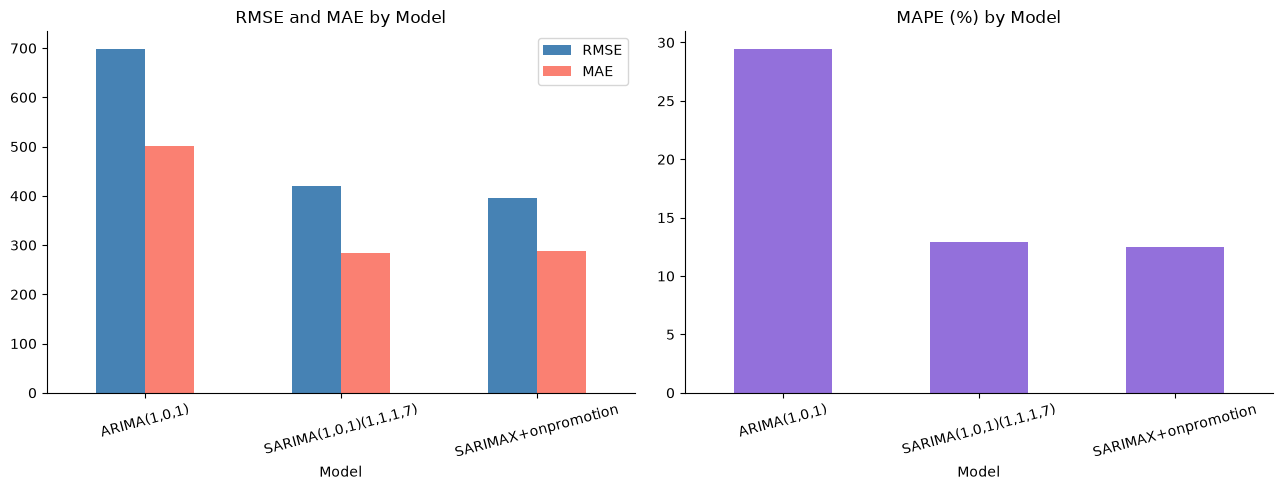

In [14]:
def evaluate(actual, forecast, label):
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae  = mean_absolute_error(actual, forecast)
    mask = actual > 0
    mape = (np.abs((actual[mask] - forecast[mask]) / actual[mask]).mean() * 100)
    return {'Model': label,
            'RMSE':  round(rmse, 2),
            'MAE':   round(mae, 2),
            'MAPE%': round(mape, 2)}

results = pd.DataFrame([
    evaluate(test.values, fc_arima.values,   'ARIMA(1,0,1)'),
    evaluate(test.values, fc_sarima.values,  'SARIMA(1,0,1)(1,1,1,7)'),
    evaluate(test.values, fc_sarimax.values, 'SARIMAX+onpromotion'),
])

print("=== Model Evaluation — 90-Day Test Set ===")
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
results.set_index('Model')[['RMSE', 'MAE']].plot(
    kind='bar', ax=axes[0], color=['steelblue', 'salmon'], rot=15)
axes[0].set_title('RMSE and MAE by Model')
results.set_index('Model')['MAPE%'].plot(
    kind='bar', ax=axes[1], color='mediumpurple', rot=15)
axes[1].set_title('MAPE (%) by Model')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/09_model_evaluation.png', dpi=150)
plt.show()

## 10. Business Interpretation

### Inventory Management Implications

| Finding | Supply Chain Action |
|---------|-------------------|
| Weekly seasonality (s=7) confirmed | Set weekly replenishment cycle — daily reorder points are inefficient |
| SARIMA beats ARIMA (RMSE -40%) | Seasonal structure is critical — flat reorder points significantly underperform |
| onpromotion coefficient = 10.3 | Pre-position ~10 units per additional promoted SKU ahead of promotion window |
| Residual autocorrelation at lag 14, 21 | Two/three-week holiday patterns remain uncaptured — motivates Prophet in Notebook 3 |
| 95% CI upper bound | Use as order-up-to level to buffer demand uncertainty |

### Connection to Perishable Inventory Research

GROCERY I contains a mix of perishable and non-perishable items.
For the perishable portion, the asymmetric cost structure applies:
under-forecasting (stockout) costs more than over-forecasting (waste).

A practical ordering rule derived from this model:

Order Quantity = SARIMAX point forecast + k * forecast standard error

where k is calibrated to the target service level (k=1.645 for 95%).

This connects directly to newsvendor and (s,S) inventory models —
the SARIMAX forecast replaces ad-hoc safety stock formulas used in practice.

### Model Limitations

- Ljung-Box residual autocorrelation at lag 14 and 21 persists across all tested
  specifications — indicates two/three-week holiday-driven demand patterns beyond
  SARIMA's structural capacity
- oil_price was excluded after AIC comparison showed no improvement over
  onpromotion-only specification — negative coefficient likely reflects
  multicollinearity with time trend rather than true causal relationship

---
*Next: Notebook 3 — Prophet Modeling (built-in holiday effects)*

In [15]:
# ── Save predictions for Notebook 4 comparison ───────────────
predictions = pd.DataFrame({
    'actual'  : test.values,
    'arima'   : fc_arima.values,
    'sarima'  : fc_sarima.values,
    'sarimax' : fc_sarimax.values,
}, index=test.index)

predictions.to_csv(f'{SAVE_DIR}/nb2_predictions.csv')
print("Predictions saved -> outputs/SARIMA/nb2_predictions.csv")
print("Next: Notebook 3 — Prophet")

Predictions saved -> outputs/SARIMA/nb2_predictions.csv
Next: Notebook 3 — Prophet
